In [276]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seed 
np.random.seed(42)

In [277]:
df = pd.read_csv('forPython.csv', sep = ';', decimal = ',')
df.head()

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
0,US,Before Thawing,0.0000,0.0000,0.00000,0.0000,0.00000,0.00000,0.00000,0.9940,0.000,0.00000,0.0000,0.00600
1,Pre-sort,Before Thawing,0.0099,0.0546,0.02208,0.0195,0.00022,0.08410,0.00066,0.0906,0.210,0.07230,0.1570,0.27904
2,Sorted,Before Thawing,0.0024,0.0000,0.00000,0.0001,0.00000,0.00025,0.00470,0.6650,0.303,0.00055,0.0016,0.02240
3,After thawing,Day 0,0.0020,0.0340,0.01640,0.0008,0.00280,0.06920,0.00000,0.0512,0.615,0.00120,0.0100,0.19740
4,US,Day 0,0.0000,0.0000,0.00000,0.0000,0.00000,0.00000,0.00000,0.9970,0.000,0.00000,0.0000,0.00300


In [278]:
# Drop columns where sample is US 
df = df[df['Sample'] != 'US']
df.head()

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
1,Pre-sort,Before Thawing,0.0099,0.0546,0.02208,0.0195,0.00022,0.08410,0.00066,0.0906,0.2100,0.07230,0.1570,0.27904
2,Sorted,Before Thawing,0.0024,0.0000,0.00000,0.0001,0.00000,0.00025,0.00470,0.6650,0.3030,0.00055,0.0016,0.02240
3,After thawing,Day 0,0.0020,0.0340,0.01640,0.0008,0.00280,0.06920,0.00000,0.0512,0.6150,0.00120,0.0100,0.19740
6,cDC1 no change,Day 1,0.0057,0.1455,0.00460,0.0011,0.00000,0.07320,0.00000,0.0378,0.0709,0.00340,0.0011,0.65670
7,cDC1 change eveyday,Day 1,0.0066,0.1458,0.00410,0.0010,0.00000,0.08180,0.00000,0.0493,0.0838,0.00200,0.0056,0.62000


In [279]:
df[df["Time"] == "Day 1"]

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
6,cDC1 no change,Day 1,0.0057,0.1455,0.00460,0.00110,0.0,0.0732,0.0,0.0378,0.0709,0.00340,0.0011,0.65670
7,cDC1 change eveyday,Day 1,0.0066,0.1458,0.00410,0.00100,0.0,0.0818,0.0,0.0493,0.0838,0.00200,0.0056,0.62000
8,HSC no change,Day 1,0.0024,0.0742,0.00079,0.00079,0.0,0.0940,0.0,0.0521,0.0711,0.00079,0.0032,0.70063
9,HSC change 1 of 2,Day 1,0.0050,0.0818,0.00000,0.00130,0.0,0.1370,0.0,0.0491,0.0957,0.00063,0.0038,0.62567


In [280]:
df_day1 = df[df["Time"] == "Day 1"]
df_day1_cDC1_nochange = df_day1[df_day1["Sample"] == "cDC1 no change"]
df_day1_cDC1_change_everyday = df_day1[df_day1["Sample"] == "cDC1 change eveyday"]
df_day1_HSC_nochange = df_day1[df_day1["Sample"] == "HSC no change"]
df_day1_HSC_change1of2 = df_day1[df_day1["Sample"] == "HSC change 1 of 2"]


In [281]:
def split_by_day (dataframe):
    sample_days = {}
    for day in dataframe["Time"].unique():
        sample_days[day] = dataframe[dataframe["Time"] == day]
    return sample_days

In [282]:
def split_by_sample(df):
    sample_dict = {}
    for sample_name in df["Sample"].unique():
        sample_dict[sample_name] = df[df["Sample"] == sample_name]

    return sample_dict


In [283]:
# colors = ["#8b95fe", "#f9afab", '#4575b4', '#91bfdb', '#ffffbf', '#313695', '#a50026', "#006948", "#5e8f81", "#6faafd", "#eea4d2", "#c7c7c7"]
colors = sns.color_palette('Spectral', n_colors=12)


In [284]:
results_by_day = split_by_day(df)
results_by_day['Day 1']

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
6,cDC1 no change,Day 1,0.0057,0.1455,0.00460,0.00110,0.0,0.0732,0.0,0.0378,0.0709,0.00340,0.0011,0.65670
7,cDC1 change eveyday,Day 1,0.0066,0.1458,0.00410,0.00100,0.0,0.0818,0.0,0.0493,0.0838,0.00200,0.0056,0.62000
8,HSC no change,Day 1,0.0024,0.0742,0.00079,0.00079,0.0,0.0940,0.0,0.0521,0.0711,0.00079,0.0032,0.70063
9,HSC change 1 of 2,Day 1,0.0050,0.0818,0.00000,0.00130,0.0,0.1370,0.0,0.0491,0.0957,0.00063,0.0038,0.62567


In [285]:
samples_day1 = split_by_sample(results_by_day['Day 1'])
samples_day1["cDC1 change eveyday"]

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
7,cDC1 change eveyday,Day 1,0.0066,0.1458,0.0041,0.001,0.0,0.0818,0.0,0.0493,0.0838,0.002,0.0056,0.62


<Figure size 1000x600 with 0 Axes>

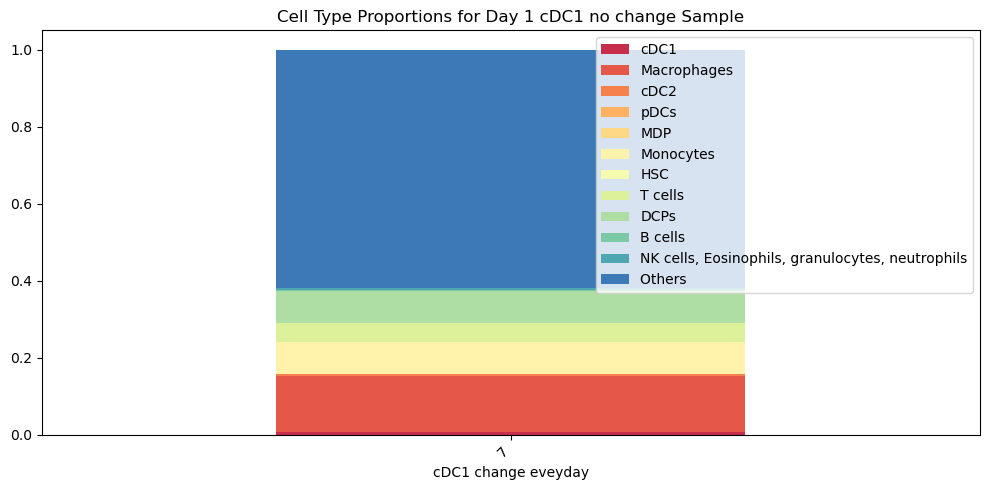

In [286]:
# Plot stacked bar chart of Cell Type proportions for Day 1 cDC1 no change sample
cell_types = [
    "cDC1", "Macrophages", "cDC2", "pDCs", "MDP", "Monocytes",
    "HSC", "T cells", "DCPs", "B cells",
    "NK cells, Eosinophils, granulocytes, neutrophils",
    "Others"
]

proportions = samples_day1["cDC1 change eveyday"].iloc[:, 2:]
proportions

proportions_plot = proportions.melt(var_name='Cell Type', value_name='Proportion')
proportions_plot
plt.figure(figsize=(10, 6))
proportions.plot(kind='bar', stacked=True, figsize=(10,5), color=colors)
plt.title('Cell Type Proportions for Day 1 cDC1 no change Sample')
plt.xlabel(samples_day1["cDC1 change eveyday"]["Sample"].values[0])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

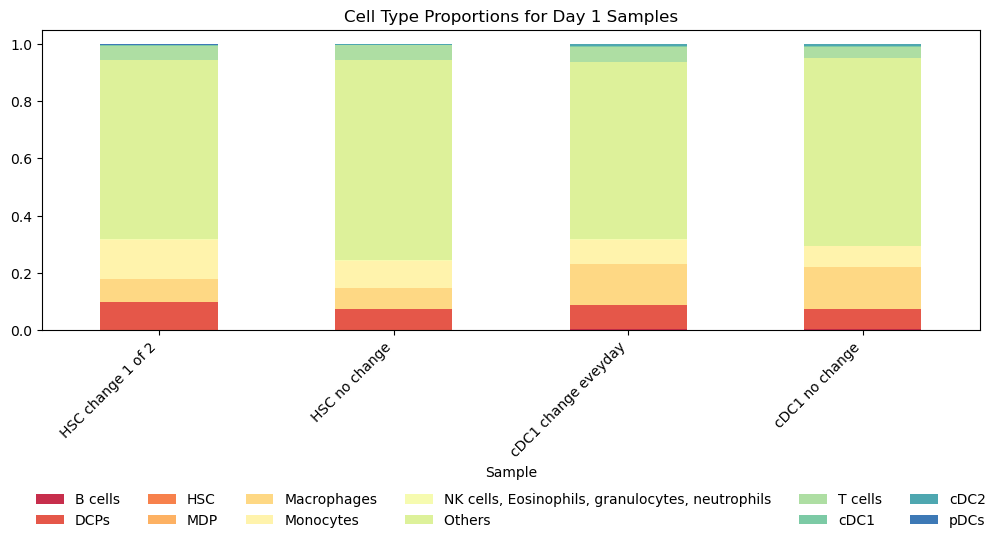

In [287]:
# Plot stacked bar chart of Cell Type proportions for Day 1 for all samples in samples_day1
proportions_all_day1 = pd.DataFrame()
for sample_name, sample_data in samples_day1.items():
    sample_proportions = sample_data.iloc[:, 2:].copy()
    sample_proportions.insert(0, 'Sample', sample_name)
    proportions_all_day1 = pd.concat([proportions_all_day1, sample_proportions], ignore_index=True)
    
proportions_all_day1_plot = proportions_all_day1.melt(id_vars='Sample', var_name='Cell Type', value_name='Proportion')
plt.figure(figsize=(10, 6))
proportions_all_plot_pivot = proportions_all_day1_plot.pivot(index='Sample', columns='Cell Type', values='Proportion')
proportions_all_plot_pivot.plot(kind='bar', stacked=True, figsize=(10,5), color=colors)
plt.title('Cell Type Proportions for Day 1 Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.50),
    ncol =6,
    frameon=False
)

plt.show()

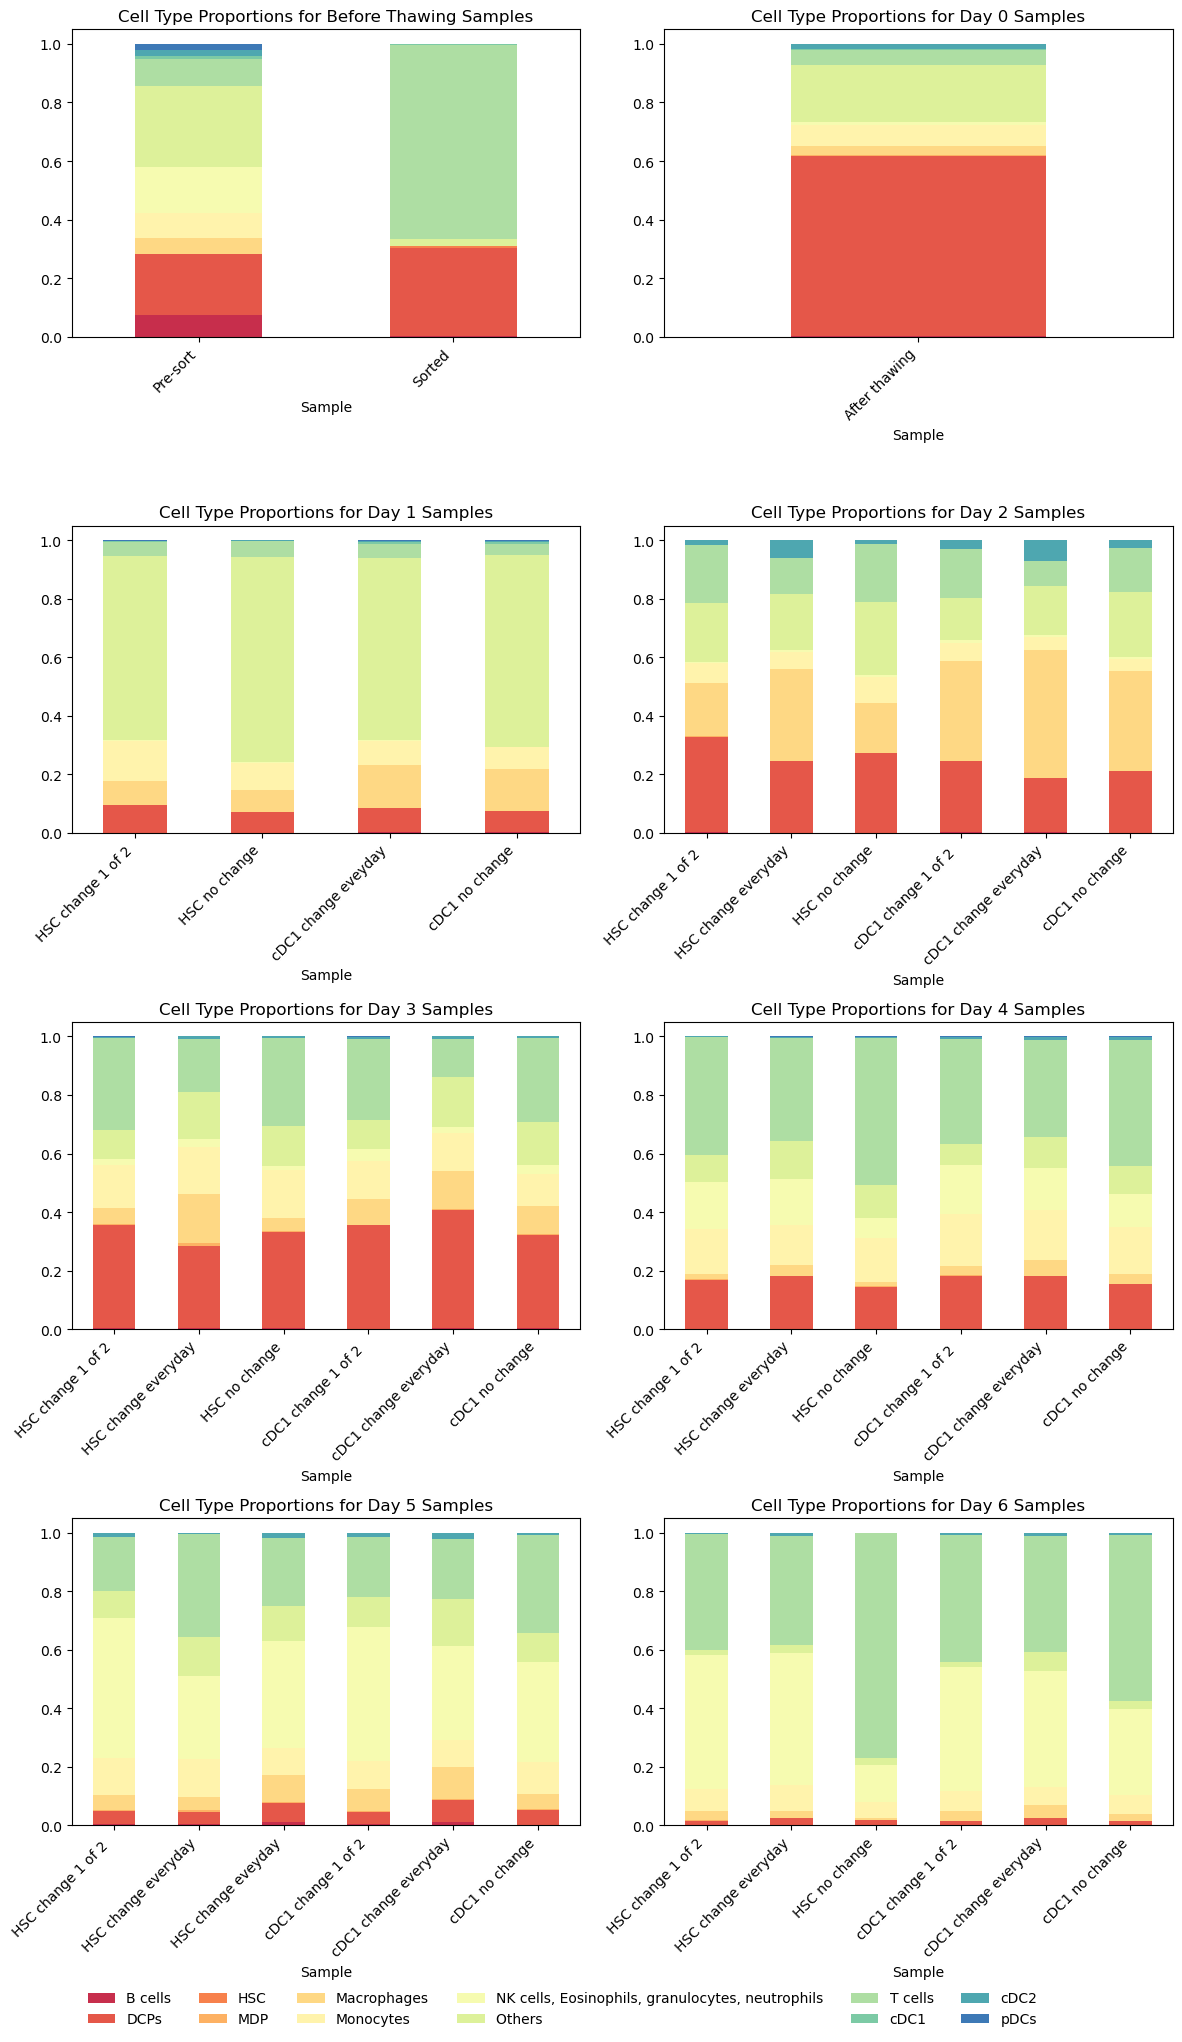

In [288]:
# Plot a figure with the 6 days with 3 lines and 2 columns
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 20))
days = list(results_by_day.keys())
for i, ax in enumerate(axes.flatten()):
    if i < len(days):
        day = days[i]
        day_data = results_by_day[day]
        day_proportions = pd.DataFrame()
        for sample_name, sample_data in split_by_sample(day_data).items():
            sample_proportions = sample_data.iloc[:, 2:].copy()
            sample_proportions.insert(0, "Sample", sample_name)
            day_proportions = pd.concat([day_proportions, sample_proportions], ignore_index=True)
        
        day_proportions_plot = day_proportions.melt(id_vars='Sample', var_name='Cell Type', value_name='Proportion')
        day_proportions_plot_pivot = day_proportions_plot.pivot(index='Sample', columns='Cell Type', values='Proportion')
        day_proportions_plot_pivot.plot(kind='bar', stacked=True, ax=ax, color=colors)
        ax.set_title(f'Cell Type Proportions for {day} Samples')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.legend_.remove()
plt.tight_layout()

plt.legend(
    loc='upper center',
    bbox_to_anchor=(-0.2, -0.5),
    ncol =6,
    frameon=False
)
plt.show()

In [289]:
dcp_proportions = df.pivot(index='Time', columns='Sample', values='DCPs')
dcp_proportions

Sample,After thawing,HSC change 1 of 2,HSC change 1 of 2,HSC change everyday,HSC change eveyday,HSC no change,Pre-sort,Sorted,cDC1 change 1 of 2,cDC1 change 1 of 2,cDC1 change everyday,cDC1 change eveyday,cDC1 no change
Time,,,,,,,,,,,,,
Before Thawing,NaN,NaN,NaN,NaN,NaN,NaN,0.21,0.303,NaN,NaN,NaN,NaN,NaN
Day 0,0.615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day 1,NaN,0.0957,NaN,NaN,NaN,0.0711,NaN,NaN,NaN,NaN,NaN,0.0838,0.0709
Day 2,NaN,NaN,0.3270,0.2440,NaN,0.2710,NaN,NaN,NaN,0.245,0.1860,NaN,0.2120
Day 3,NaN,0.3540,NaN,0.2810,NaN,0.3270,NaN,NaN,NaN,0.354,0.4010,NaN,0.3200
Day 4,NaN,0.1680,NaN,0.1800,NaN,0.1450,NaN,NaN,NaN,0.181,0.1810,NaN,0.1530
Day 5,NaN,NaN,0.0432,0.0431,0.0676,NaN,NaN,NaN,0.0392,NaN,0.0738,NaN,0.0482
Day 6,NaN,0.0145,NaN,0.0249,NaN,0.0179,NaN,NaN,0.0134,NaN,0.0247,NaN,0.0146


In [290]:
# Merge columns two columns "HSC change 1 of 2 
dcp_proportions['HSC change 1 of 2 new'] = dcp_proportions[['HSC change 1 of 2', 'HSC change 1 of 2 ']].sum(axis=1)
dcp_proportions = dcp_proportions.drop(columns=['HSC change 1 of 2', 'HSC change 1 of 2 '])
dcp_proportions["HSC change 1 of 2"] = dcp_proportions['HSC change 1 of 2 new']
dcp_proportions.drop(columns=['HSC change 1 of 2 new'], inplace=True)


In [291]:
# Merge columns two columns "cDC1 change 1 of 2
dcp_proportions['cDC1 change 1 of 2 new'] = dcp_proportions[['cDC1 change 1 of 2', 'cDC1 change 1 of 2 ']].sum(axis=1)
dcp_proportions = dcp_proportions.drop(columns=['cDC1 change 1 of 2', 'cDC1 change 1 of 2 '])
dcp_proportions["cDC1 change 1 of 2"] = dcp_proportions['cDC1 change 1 of 2 new']
dcp_proportions.drop(columns=['cDC1 change 1 of 2 new'], inplace=True)

dcp_proportions

Sample,After thawing,HSC change everyday,HSC change eveyday,HSC no change,Pre-sort,Sorted,cDC1 change everyday,cDC1 change eveyday,cDC1 no change,HSC change 1 of 2,cDC1 change 1 of 2
Time,,,,,,,,,,,
Before Thawing,NaN,NaN,NaN,NaN,0.21,0.303,NaN,NaN,NaN,0.0000,0.0000
Day 0,0.615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000
Day 1,NaN,NaN,NaN,0.0711,NaN,NaN,NaN,0.0838,0.0709,0.0957,0.0000
Day 2,NaN,0.2440,NaN,0.2710,NaN,NaN,0.1860,NaN,0.2120,0.3270,0.2450
Day 3,NaN,0.2810,NaN,0.3270,NaN,NaN,0.4010,NaN,0.3200,0.3540,0.3540
Day 4,NaN,0.1800,NaN,0.1450,NaN,NaN,0.1810,NaN,0.1530,0.1680,0.1810
Day 5,NaN,0.0431,0.0676,NaN,NaN,NaN,0.0738,NaN,0.0482,0.0432,0.0392
Day 6,NaN,0.0249,NaN,0.0179,NaN,NaN,0.0247,NaN,0.0146,0.0145,0.0134


In [292]:
df_before_thawing = df[df["Time"] == "Before Thawing"]
df_before_thawing

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
1,Pre-sort,Before Thawing,0.0099,0.0546,0.02208,0.0195,0.00022,0.08410,0.00066,0.0906,0.210,0.07230,0.1570,0.27904
2,Sorted,Before Thawing,0.0024,0.0000,0.00000,0.0001,0.00000,0.00025,0.00470,0.6650,0.303,0.00055,0.0016,0.02240


In [293]:
df_day0 = df[df["Time"] == "Day 0"]
df_day0

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
3,After thawing,Day 0,0.002,0.034,0.0164,0.0008,0.0028,0.0692,0.0,0.0512,0.615,0.0012,0.01,0.1974


In [294]:
# Add df_day 0 after df_before thawing
df_1st_days = pd.concat([df_before_thawing, df_day0], ignore_index=True)
df_1st_days

,Sample,Time,cDC1,Macrophages,cDC2,pDCs,MDP,Monocytes,HSC,T cells,DCPs,B cells,"NK cells, Eosinophils, granulocytes, neutrophils",Others
0,Pre-sort,Before Thawing,0.0099,0.0546,0.02208,0.0195,0.00022,0.08410,0.00066,0.0906,0.210,0.07230,0.1570,0.27904
1,Sorted,Before Thawing,0.0024,0.0000,0.00000,0.0001,0.00000,0.00025,0.00470,0.6650,0.303,0.00055,0.0016,0.02240
2,After thawing,Day 0,0.0020,0.0340,0.01640,0.0008,0.00280,0.06920,0.00000,0.0512,0.615,0.00120,0.0100,0.19740


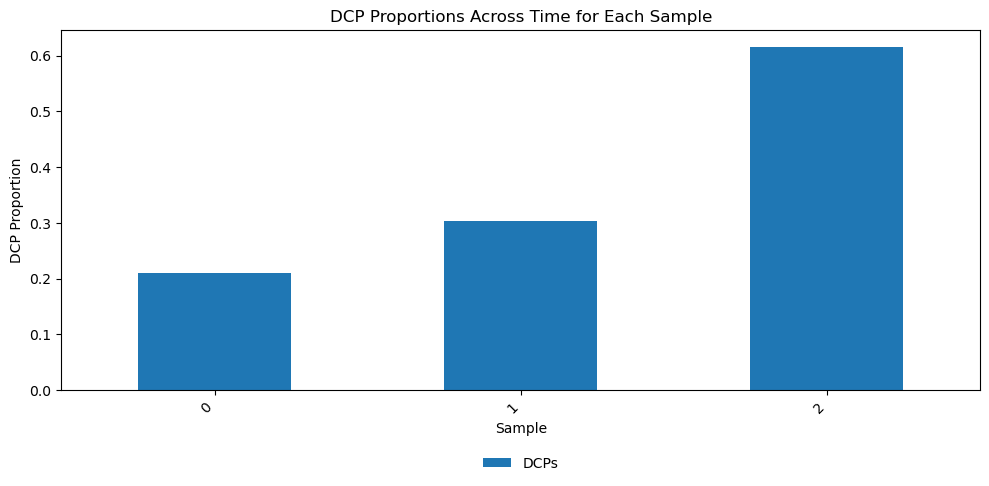

In [295]:
# Plot bar chart of DCP proportions on first days
df_1st_days["DCPs"].plot(kind='bar', figsize=(10,5))
plt.title('DCP Proportions Across Time for Each Sample')
plt.xlabel('Sample')
plt.ylabel('DCP Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol =6,
    frameon=False
)
plt.tight_layout()
plt.show()  

In [296]:
dcp_proportions.drop(columns=['Pre-sort', 'Sorted'], inplace=True)


<Figure size 1000x600 with 0 Axes>

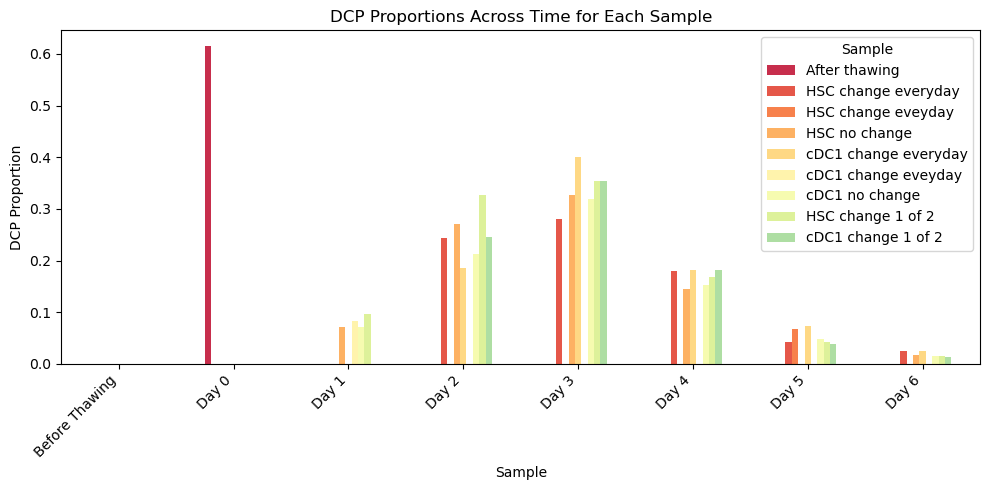

In [297]:
# Plot bar chart of DCP proportions across time for each sample
plt.figure(figsize=(10, 6))
dcp_proportions.plot(kind='bar', figsize=(10,5), color=colors)
plt.title('DCP Proportions Across Time for Each Sample')
plt.xlabel('Sample')
plt.ylabel('DCP Proportion')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()  